# explicar_cliente — Waterfall SHAP por cliente

Ferramenta de validação: troca o `CLIENTE_ID` abaixo e roda de novo pra ver por que
o modelo deu aquele score pra qualquer cliente. Não é parte do pipeline (treino ou
inferência) — é só uma lupa pra inspecionar casos individuais.

**Importante:** lê `features_scoring_atual.parquet` (dado AO VIVO, gerado por
`scripts/scoring_mensal.py`) — nunca `df_model_teste.parquet` (snapshot congelado).
Rode `scoring_mensal.py` antes se ainda não rodou neste ciclo.

In [1]:
import sys, pickle
from pathlib import Path

import pandas as pd
import shap

PROJECT_ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT))
import os
os.chdir(PROJECT_ROOT)

from src.config import PROCESSED_DIR
from src.model_prep import preparar_X

FEATURES_PATH = PROCESSED_DIR / "features_scoring_atual.parquet"

with open(PROCESSED_DIR / "modelo_churn.pkl", "rb") as f:
    artefatos = pickle.load(f)
modelo      = artefatos["modelo"]
modelo_nome = artefatos["modelo_nome"]
calibrador  = artefatos["calibrador"]
features    = artefatos["features"]

if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"{FEATURES_PATH} não existe ainda — rode scripts/scoring_mensal.py primeiro."
    )
df_teste  = pd.read_parquet(FEATURES_PATH)
explainer = shap.TreeExplainer(modelo)

print(f"Modelo carregado: {modelo_nome}")
print(f"Clientes disponíveis (ciclo atual): {df_teste['CLIENTE'].nunique()}")

C:\Users\carva\OneDrive\Área de Trabalho\central_eto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo carregado: XGBoost (default)
Clientes disponíveis (ciclo atual): 776


---
### Troque o `CLIENTE_ID` aqui e rode as duas células abaixo

In [2]:
CLIENTE_ID = 1539  # <-- troque aqui e rode de novo

In [3]:
row = df_teste[df_teste["CLIENTE"] == CLIENTE_ID]
if row.empty:
    raise ValueError(f"Cliente {CLIENTE_ID} não encontrado em features_scoring_atual.parquet")

X = preparar_X(row, features)

p_bruta     = modelo.predict_proba(X)[:, 1][0]
p_calibrada = calibrador.predict_proba(X)[:, 1][0]
nome        = row["NOME"].values[0].strip()

print(f"Cliente {CLIENTE_ID} — {nome}")
print(f"  p_churn_bruta     : {p_bruta:.3f}")
print(f"  p_churn_calibrada : {p_calibrada:.3f}")

Cliente 1539 — PATHOS OFTALMOLOGIA LTDA
  p_churn_bruta     : 0.749
  p_churn_calibrada : 0.839


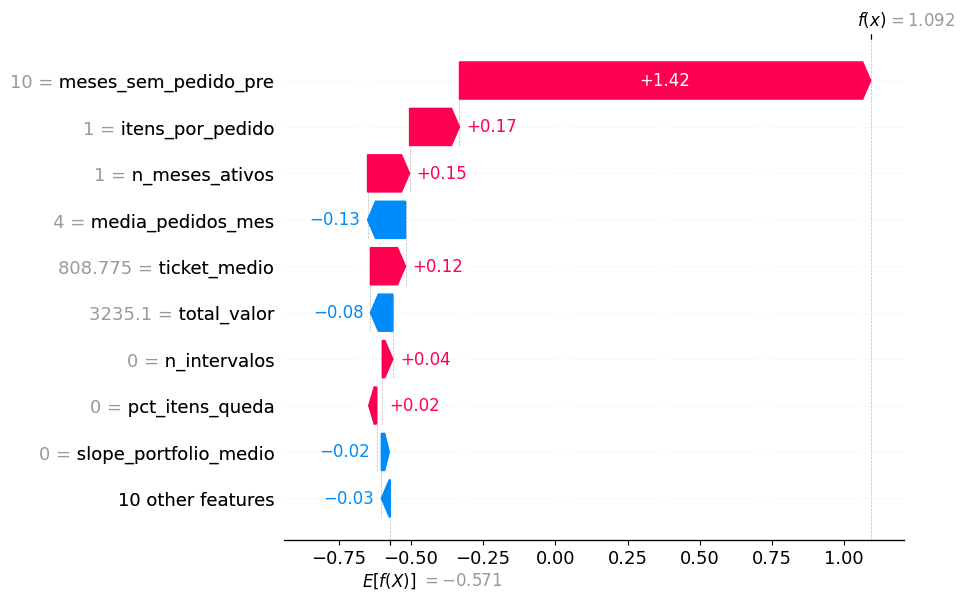

In [4]:
shap_vals = explainer(X)
shap.plots.waterfall(shap_vals[0], show=True)